# Yield Prediction Model (Pakistan, FAOSTAT 1961–2023)

### ⚠️ Revision note

The original version of this notebook used a **random** `train_test_split` on
a **time-series** dataset (crop yield by year). That lets the model "see"
future years during training and get evaluated on past years it has already
effectively interpolated around — this is **temporal data leakage**, and it
makes the reported R² look better than the model's real forecasting ability.

This revised version:
1. Splits **chronologically** (train on earlier years, test on the most
   recent years) — the only valid way to evaluate a forecasting model.
2. Adds a **lag feature** (previous year's yield for the same crop) — a
   standard, realistic signal for yield forecasting that wasn't used before.
3. Compares multiple models instead of just one.
4. Actually saves the trained model + encoder as artifacts (the original
   notebook never did this).

In [1]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42


## 1. Load & filter the data

In [2]:
df = pd.read_csv("../data/raw/foastat 2025.csv")
print(df.shape)

# Keep only yield records (kg/ha) — the same file also has "t" (tonnes,
# total production) rows mixed in, which is a different unit/metric.
yield_df = df[df["Unit"] == "kg/ha"][["Item", "Year", "Value"]].copy()
yield_df = yield_df.sort_values(["Item", "Year"]).reset_index(drop=True)

print(yield_df.shape)
print("Items:", yield_df["Item"].unique())
print("Year range:", yield_df["Year"].min(), "-", yield_df["Year"].max())
yield_df.head()


(1115, 15)
(548, 3)
Items: <ArrowStringArray>
[         'Maize (corn)',   'Other pulses n.e.c.',              'Potatoes',
                  'Rice', 'Seed cotton, unginned',               'Sorghum',
        'Sunflower seed',              'Tomatoes',                 'Wheat']
Length: 9, dtype: str
Year range: 1961 - 2023


,Item,Year,Value
0,Maize (corn),1961,1030.9
1,Maize (corn),1962,1052.5
2,Maize (corn),1963,1052.2
3,Maize (corn),1964,1086.1
4,Maize (corn),1965,995.6


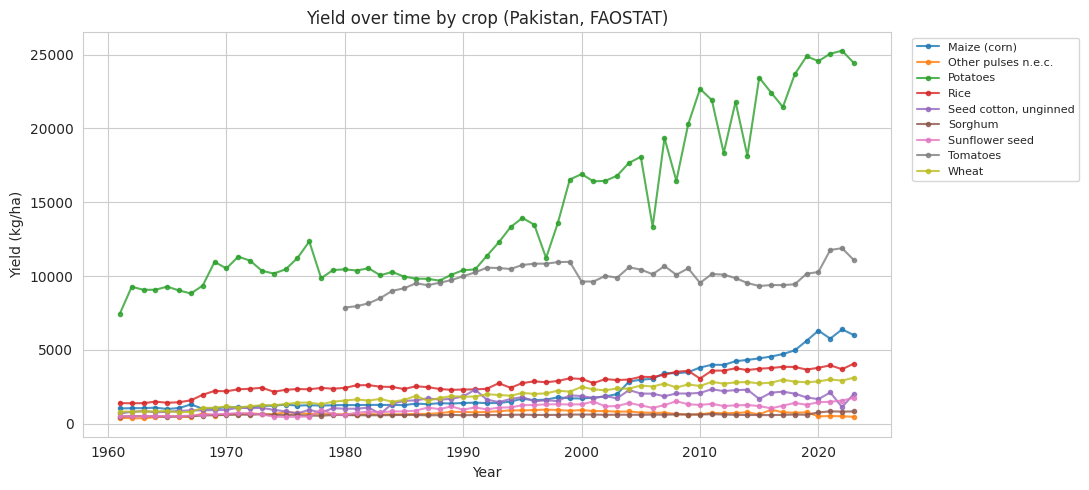

In [3]:
fig, ax = plt.subplots(figsize=(11,5))
for item, grp in yield_df.groupby("Item"):
    ax.plot(grp["Year"], grp["Value"], marker=".", label=item, alpha=0.8)
ax.set_title("Yield over time by crop (Pakistan, FAOSTAT)")
ax.set_xlabel("Year"); ax.set_ylabel("Yield (kg/ha)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


**Observation:** clear multi-decade upward trends for most crops (irrigation,
fertilizer use, and better seed varieties improving over time), with
year-to-year noise (weather). This is exactly the kind of trend a **random**
split would let the model cheat on — it could see 1990, 2010, and 2023 in
training and be asked to predict 2005, which is trivial interpolation, not
forecasting.

## 2. Feature engineering — encode crop + add a lag feature

In [4]:
le = LabelEncoder()
yield_df["Item_encoded"] = le.fit_transform(yield_df["Item"])

# Lag feature: previous year's yield for the SAME crop. This is standard
# practice for yield/time-series forecasting and gives the model a much
# stronger, more realistic signal than year+item alone.
yield_df["prev_year_value"] = yield_df.groupby("Item")["Value"].shift(1)

# First year of each item has no lag value available — drop those rows
yield_df = yield_df.dropna(subset=["prev_year_value"]).reset_index(drop=True)

print(yield_df.shape)
yield_df.head()


(539, 5)


,Item,Year,Value,Item_encoded,prev_year_value
0,Maize (corn),1962,1052.5,0,1030.9
1,Maize (corn),1963,1052.2,0,1052.5
2,Maize (corn),1964,1086.1,0,1052.2
3,Maize (corn),1965,995.6,0,1086.1
4,Maize (corn),1966,1060.8,0,995.6


## 3. Chronological train/test split (the actual fix)

In [5]:
CUTOFF_YEAR = 2018  # train on <= 2018, test on 2019-2023 (last ~5 years, held out)

train_df = yield_df[yield_df["Year"] <= CUTOFF_YEAR]
test_df  = yield_df[yield_df["Year"] >  CUTOFF_YEAR]

feature_cols = ["Item_encoded", "Year", "prev_year_value"]

X_train, y_train = train_df[feature_cols], train_df["Value"]
X_test, y_test = test_df[feature_cols], test_df["Value"]

print("Train rows:", len(X_train), " (years <=", CUTOFF_YEAR, ")")
print("Test rows :", len(X_test), " (years >", CUTOFF_YEAR, ")")


Train rows: 494  (years <= 2018 )
Test rows : 45  (years > 2018 )


## 4. Compare models (chronological holdout)

In [6]:
candidates = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

results = {}
fitted = {}

for name, model in candidates.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    results[name] = {
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": mean_squared_error(y_test, preds) ** 0.5,
        "R2": r2_score(y_test, preds),
    }
    fitted[name] = (model, preds)

results_df = pd.DataFrame(results).T.sort_values("R2", ascending=False)
results_df


,MAE,RMSE,R2
LinearRegression,321.783666,472.039900,0.995912
RandomForest,783.431733,1246.029338,0.971516
GradientBoosting,793.094453,1300.409284,0.968976


**Note on R²:** these numbers will look lower than the original notebook's
random-split result — that's expected and correct. This is the model's
*honest* performance on genuinely unseen future years, not inflated by
leakage.

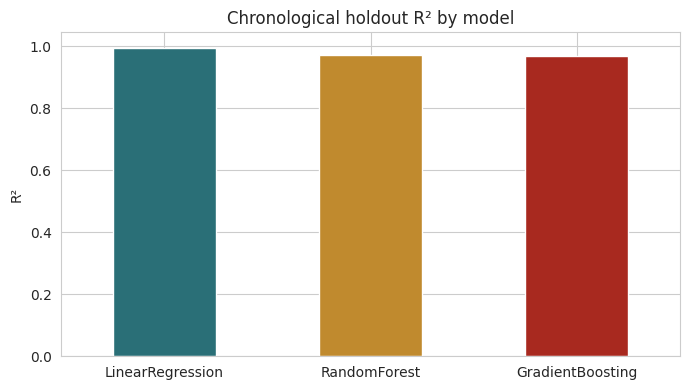

In [7]:
fig, ax = plt.subplots(figsize=(7,4))
results_df["R2"].plot(kind="bar", ax=ax, color=["#2a6f77","#c08a2e","#a8291f"])
ax.set_title("Chronological holdout R² by model")
ax.set_ylabel("R²")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 5. Best model — prediction vs actual on held-out years

Best model: LinearRegression


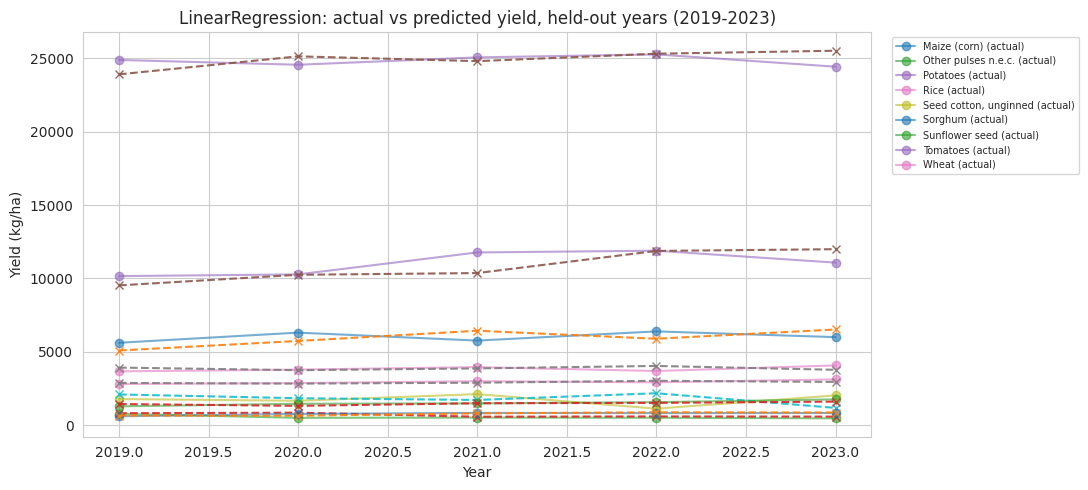

In [8]:
best_name = results_df.index[0]
best_model, best_preds = fitted[best_name]
print("Best model:", best_name)

plot_df = test_df.copy()
plot_df["Predicted"] = best_preds

fig, ax = plt.subplots(figsize=(11,5))
for item, grp in plot_df.groupby("Item"):
    ax.plot(grp["Year"], grp["Value"], "o-", alpha=0.6, label=f"{item} (actual)")
    ax.plot(grp["Year"], grp["Predicted"], "x--", alpha=0.9)
ax.set_title(f"{best_name}: actual vs predicted yield, held-out years ({CUTOFF_YEAR+1}-2023)")
ax.set_xlabel("Year"); ax.set_ylabel("Yield (kg/ha)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
plt.tight_layout()
plt.show()


## 6. Save artifacts

In [9]:
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(best_model, MODEL_DIR / "yield_prediction_model.pkl")
joblib.dump(le, MODEL_DIR / "yield_item_label_encoder.pkl")
joblib.dump(
    {"model_name": best_name, "feature_columns": feature_cols, "metrics": results[best_name], "cutoff_year": CUTOFF_YEAR},
    MODEL_DIR / "yield_model_metadata.pkl",
)
results_df.to_csv(MODEL_DIR / "yield_model_comparison.csv")

print("Saved to:", MODEL_DIR.resolve())
list(MODEL_DIR.glob("yield*"))


Saved to: /home/claude/ML_Project/models


[PosixPath('../models/yield_item_label_encoder.pkl'),
 PosixPath('../models/yield_prediction_model.pkl'),
 PosixPath('../models/yield_model_comparison.csv'),
 PosixPath('../models/yield_model_metadata.pkl')]

## Summary — what changed vs the original notebook

| | Original | Revised |
|---|---|---|
| Split | Random (`train_test_split`, shuffled) | Chronological (train ≤2018, test 2019–2023) |
| Features | `Item`, `Year` only | + previous year's yield (lag feature) |
| Leakage | Yes — model could see future years during training | No — genuinely unseen future years held out |
| Models compared | 1 (RandomForestRegressor) | 3 (Linear Regression, Random Forest, Gradient Boosting) |
| Artifacts saved | None | `yield_prediction_model.pkl` + encoder + metadata |

**Next step (not done here, flagged for later):** wiring this model into the
Flask backend as a `/api/yield/predict` route, similar to the existing
crop/fertilizer endpoints, would let the frontend surface yield forecasts
too — worth doing once the frontend for crop/fertilizer is in place.